# Practical Exercises

This notebook shows practical ways to use `stock-analysis-program` for stock research, charting, screening, comparison, and reporting. The examples use common tickers so you can run them as-is, then replace the symbols with your own watchlist.

> These exercises are for educational analysis only and are not financial advice.

## Setup

Import the package classes used throughout the notebook. If you are running this from an installed PyPI package, use `pip install stock-analysis-program` first.

In [ ]:
from stock_analysis_program import (
    CurrentPricesTickerDisplay,
    FinancialMetricsFetcher,
    FinancialMetricsPlotter,
    RevenueGrowthFetcher,
    RevenueGrowthPlotter,
    StockDataFetcher,
    StockExchangePerformancePlotter,
    StockPricePlotter,
    StockSummaryFetcher,
    StockVolatilityPlotter,
)

WATCHLIST = ["AAPL", "MSFT", "GOOGL"]
START_DATE = "2023-01-01"
END_DATE = "2024-01-01"


## 1. Quick Stock Price Charting

Practical use: quickly visualize a stock's historical closing price to understand its general trend over a chosen period. This is useful as a first look before doing deeper fundamental or technical analysis.

c:\Python\Python313\Lib\site-packages\stock_analysis_program\plotter\stock_price_plotter.py:41: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


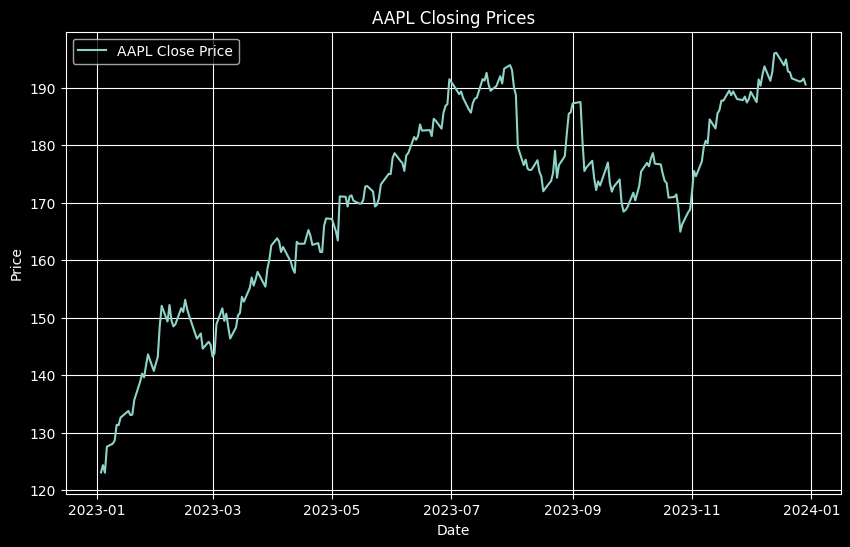

In [ ]:
price_plotter = StockPricePlotter("AAPL")
price_plotter.plot_closing_prices(START_DATE, END_DATE)


## 2. Moving Average Analysis

Practical use: moving averages smooth price action and help highlight trend direction. A short moving average can show recent momentum, while a longer one can show broader trend strength.

c:\Python\Python313\Lib\site-packages\stock_analysis_program\plotter\stock_price_plotter.py:62: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


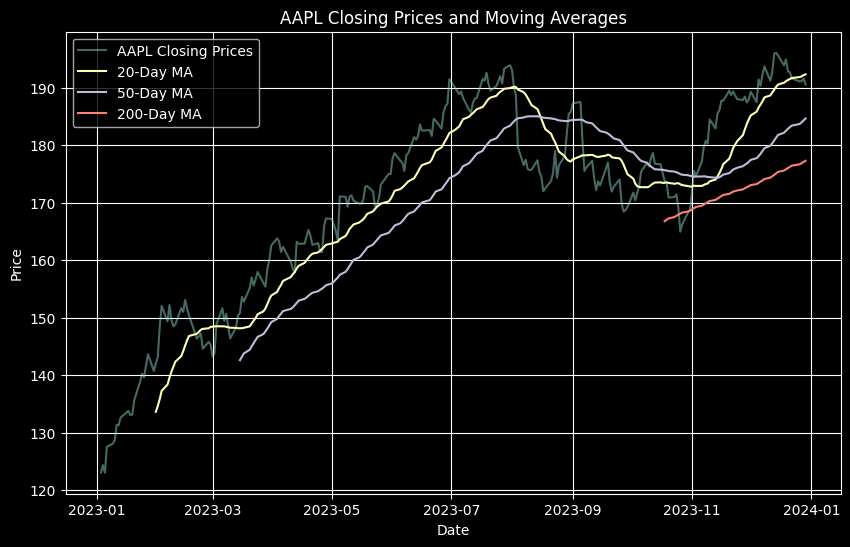

In [ ]:
price_plotter.plot_moving_averages(
    START_DATE,
    END_DATE,
    window_sizes=[20, 50, 200],
)


## 3. Basic Stock Screening

Practical use: collect valuation and profitability metrics for a watchlist. This can help identify which companies deserve deeper research based on market cap, P/E ratio, price-to-book, and profit margins.

In [ ]:
metrics_fetcher = FinancialMetricsFetcher(WATCHLIST)
financial_metrics = metrics_fetcher.fetch_financial_metrics()
financial_metrics


,Ticker,Market Cap,PE Ratio,Forward PE,Price to Book,Profit Margins
0,AAPL,4109006274560,33.915257,29.386591,46.705570,0.27152
1,MSFT,3078640631808,24.698450,21.452034,7.876841,0.39342
2,GOOGL,4672805404672,29.419529,27.129019,11.227258,0.37919


## 4. Portfolio Comparison

Practical use: compare multiple holdings or candidates visually over the same period. This can help you see which stock outperformed and when relative momentum changed.

c:\Python\Python313\Lib\site-packages\stock_analysis_program\plotter\stock_price_plotter.py:41: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


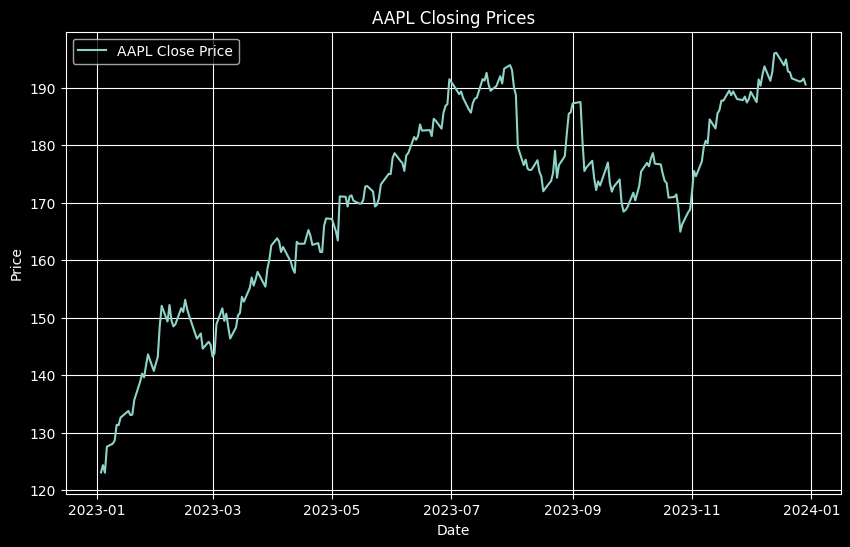

c:\Python\Python313\Lib\site-packages\stock_analysis_program\plotter\stock_price_plotter.py:41: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


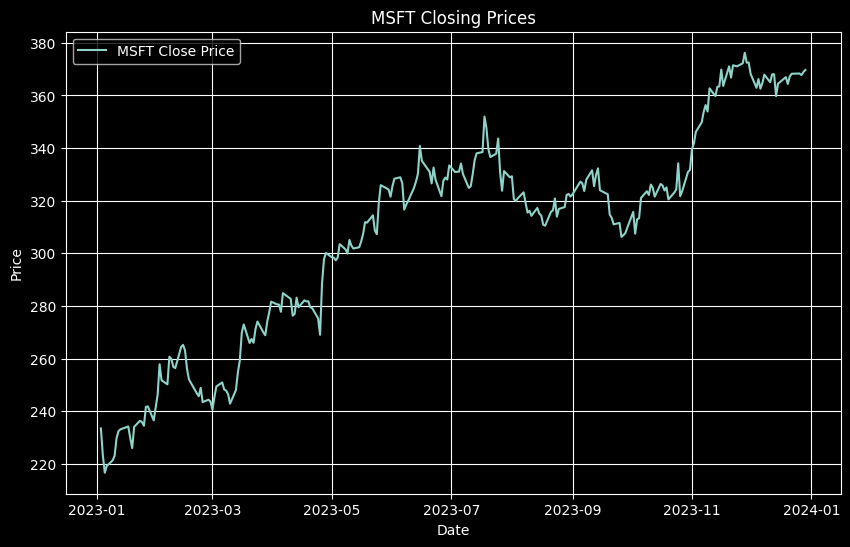

c:\Python\Python313\Lib\site-packages\stock_analysis_program\plotter\stock_price_plotter.py:41: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


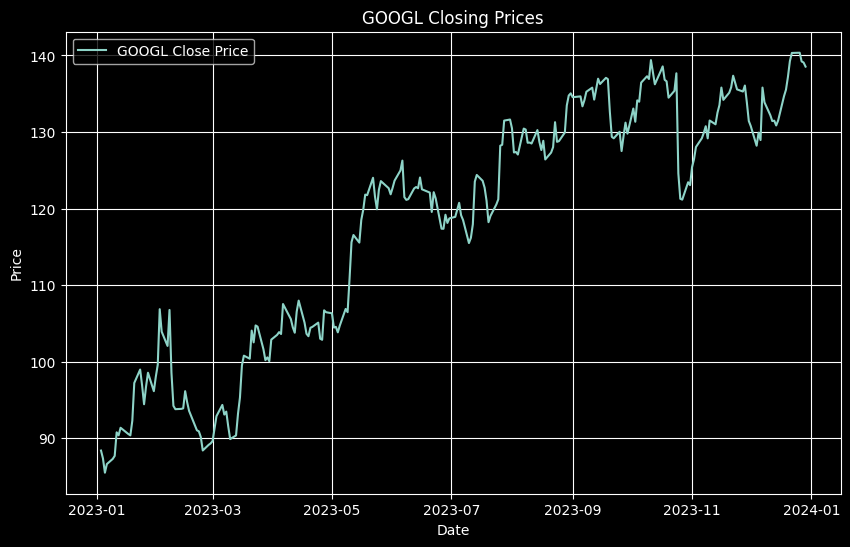

In [ ]:
portfolio_plotter = StockPricePlotter(WATCHLIST)
portfolio_plotter.plot_closing_prices(START_DATE, END_DATE)


## 5. Index Performance Comparison

Practical use: compare broad market indexes such as the S&P 500, Dow Jones Industrial Average, and Nasdaq Composite. Normalized prices make relative performance easier to compare.

c:\Python\Python313\Lib\site-packages\stock_analysis_program\plotter\stock_exchange_performance_plotter.py:51: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(index, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
c:\Python\Python313\Lib\site-packages\stock_analysis_program\plotter\stock_exchange_performance_plotter.py:51: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(index, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
c:\Python\Python313\Lib\site-packages\stock_analysis_program\plotter\stock_exchange_performance_plotter.py:51: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(index, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


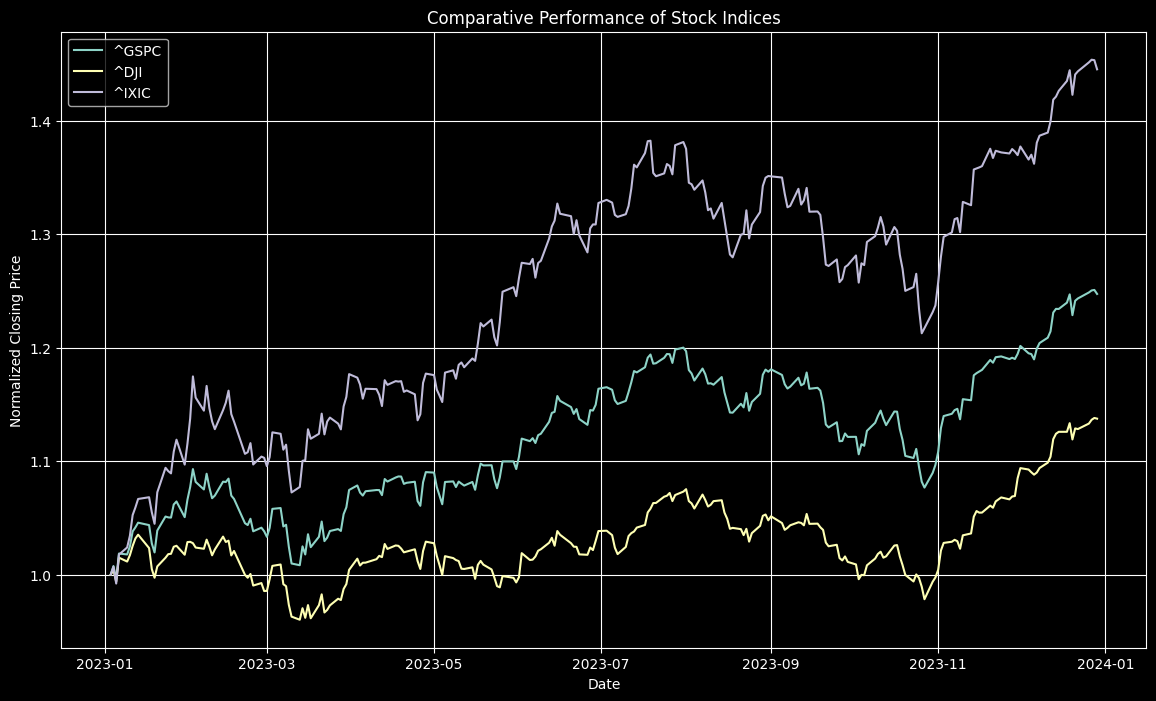

In [ ]:
index_plotter = StockExchangePerformancePlotter(["^GSPC", "^DJI", "^IXIC"])
index_plotter.plot_performance(START_DATE, END_DATE)


## 6. Revenue Growth Checks

Practical use: revenue growth can show whether a company's top line is expanding or slowing. This is useful for comparing business momentum across several companies.

In [ ]:
growth_fetcher = RevenueGrowthFetcher(WATCHLIST)
revenue_growth = growth_fetcher.fetch_revenue_growth()
revenue_growth


c:\Python\Python313\Lib\site-packages\stock_analysis_program\fetcher\revenue_growth_fetcher.py:48: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  revenue_growth = revenue.pct_change(periods=-1)  # Negative periods for year-over-year growth


{'AAPL': np.float64(0.06425511782832749),
 'MSFT': np.float64(0.14932156232406713),
 'GOOGL': np.float64(0.1509008108154437)}

## 7. Revenue Growth Visualization

Practical use: a chart can make revenue growth comparisons easier to scan than raw numbers, especially when reviewing several companies at once.

c:\Python\Python313\Lib\site-packages\stock_analysis_program\fetcher\revenue_growth_fetcher.py:48: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  revenue_growth = revenue.pct_change(periods=-1)  # Negative periods for year-over-year growth


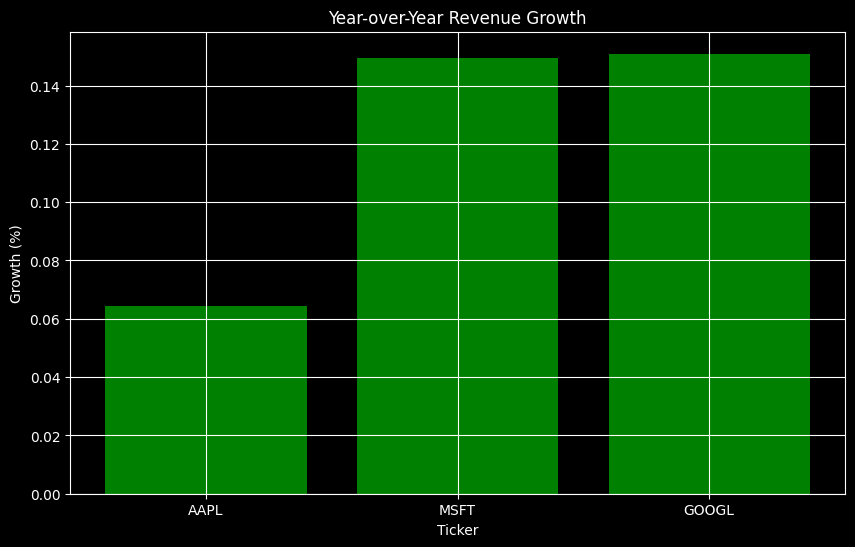

In [ ]:
growth_plotter = RevenueGrowthPlotter(WATCHLIST)
growth_plotter.plot_revenue_growth()


## 8. Volatility Analysis

Practical use: rolling volatility helps estimate how much a stock's returns fluctuate. This is useful when comparing risk across stocks or deciding whether a position matches your risk tolerance.

c:\Python\Python313\Lib\site-packages\stock_analysis_program\plotter\stock_volatility_plotter.py:44: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
c:\Python\Python313\Lib\site-packages\stock_analysis_program\plotter\stock_volatility_plotter.py:44: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
c:\Python\Python313\Lib\site-packages\stock_analysis_program\plotter\stock_volatility_plotter.py:44: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


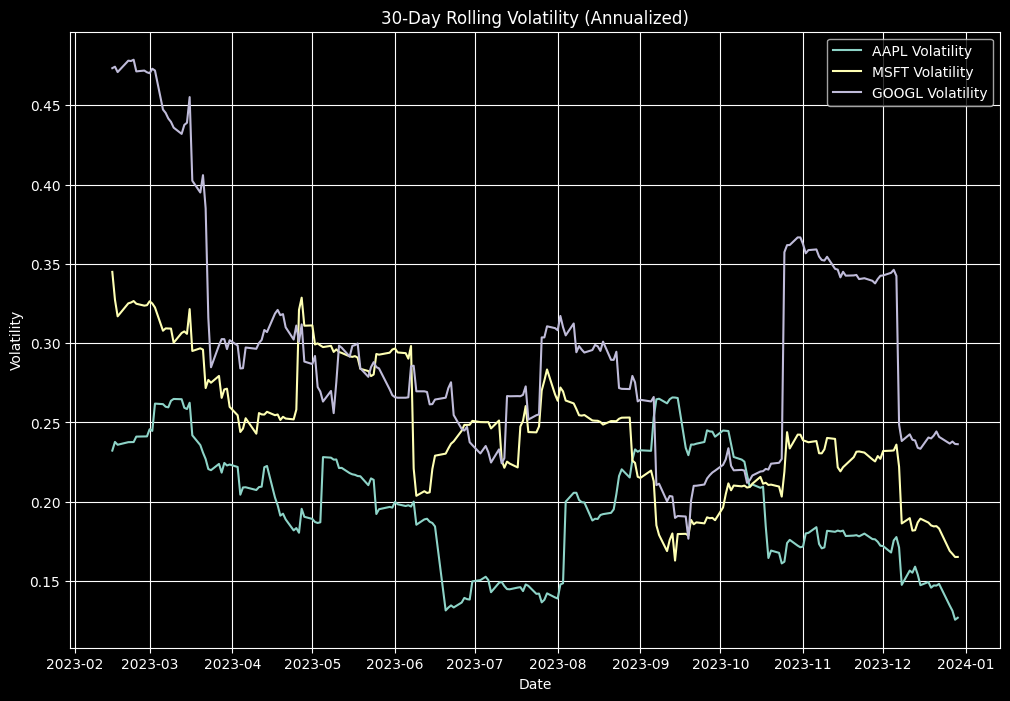

In [ ]:
volatility_plotter = StockVolatilityPlotter(WATCHLIST)
volatility_plotter.plot_volatility(
    START_DATE,
    END_DATE,
    window_size=30,
)


## 9. Watchlist Summaries

Practical use: fetch a quick company overview for each ticker, including name, sector, industry, exchange, country, market cap, and other summary fields.

In [ ]:
summary_fetcher = StockSummaryFetcher(WATCHLIST)
summaries = summary_fetcher.get_summaries()
summaries


[{'Name': 'Apple Inc.',
  'Sector': 'Technology',
  'Industry': 'Consumer Electronics',
  'Country': 'United States',
  'Exchange': 'NMS',
  'Website': 'https://www.apple.com',
  'Summary': 'Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. The company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; and wearables, home, and accessories comprising AirPods, Apple Vision Pro, Apple TV, Apple Watch, Beats products, and HomePod, as well as Apple branded and third-party accessories. It also provides AppleCare support and cloud services; and operates various platforms, including the App Store that allow customers to discover and download applications and digital content, such as books, music, video, games, and podcasts, as well as advertising services include third-party licensing arrangements and its own advertising platforms. In addition, the company of

## 10. Average Volume and Moving Average Data

Practical use: average volume can help judge liquidity, while computed moving average series can be reused in custom models, reports, or dashboards.

In [ ]:
data_fetcher = StockDataFetcher("AAPL")
historical_data = data_fetcher.fetch_historical_data(period="1y")
average_volume = data_fetcher.get_average_volume(historical_data)
moving_averages = data_fetcher.calculate_moving_averages(
    historical_data, window_sizes=[20, 50]
)

average_volume, moving_averages.keys()


(np.float64(50270634.26294821), dict_keys(['20-day MA', '50-day MA']))

## 11. Current Price Checks

Practical use: fetch current prices for a watchlist when you need a simple snapshot. In scripts or dashboards, use `fetch_current_prices()` instead of the continuous CLI-style ticker display.

In [ ]:
ticker_display = CurrentPricesTickerDisplay(WATCHLIST, interval=10)
current_prices = ticker_display.fetch_current_prices()
current_prices


{'AAPL': 280.14, 'MSFT': 414.44, 'GOOGL': 385.69}

## 12. Automated Reporting Starter

Practical use: combine metrics, summaries, and charts into a repeatable workflow. This pattern can be scheduled daily, weekly, or monthly to generate a consistent watchlist report.

In [ ]:
def build_watchlist_snapshot(tickers):
    metrics = FinancialMetricsFetcher(tickers).fetch_financial_metrics()
    growth = RevenueGrowthFetcher(tickers).fetch_revenue_growth()
    summaries = StockSummaryFetcher(tickers).get_summaries()
    return {
        "metrics": metrics,
        "revenue_growth": growth,
        "summaries": summaries,
    }


snapshot = build_watchlist_snapshot(WATCHLIST)
snapshot["metrics"]


c:\Python\Python313\Lib\site-packages\stock_analysis_program\fetcher\revenue_growth_fetcher.py:48: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  revenue_growth = revenue.pct_change(periods=-1)  # Negative periods for year-over-year growth


,Ticker,Market Cap,PE Ratio,Forward PE,Price to Book,Profit Margins
0,AAPL,4109006274560,33.915257,29.386591,46.705570,0.27152
1,MSFT,3078640631808,24.698450,21.452034,7.876841,0.39342
2,GOOGL,4672805404672,29.419529,27.129019,11.227258,0.37919


## 13. Sector or Peer Comparison

Practical use: compare companies in the same broad peer group. This example uses large technology companies, but you can swap in banks, energy companies, retailers, healthcare firms, or any custom peer set.

In [ ]:
tech_peers = ["AAPL", "MSFT", "GOOGL", "META"]
peer_metrics = FinancialMetricsFetcher(tech_peers).fetch_financial_metrics()
peer_metrics


,Ticker,Market Cap,PE Ratio,Forward PE,Price to Book,Profit Margins
0,AAPL,4109006274560,33.915257,29.386591,46.705570,0.27152
1,MSFT,3078640631808,24.698450,21.452034,7.876841,0.39342
2,GOOGL,4672805404672,29.419529,27.129019,11.227258,0.37919
3,META,1545252503552,22.120094,16.826385,7.089394,0.32837


## 14. Report-Friendly Plotting

Practical use: plotter methods can be used inside notebooks or reporting scripts. With the current published package, the methods display plots directly; for saved reports, generate the chart and then save the active Matplotlib figure.

c:\Python\Python313\Lib\site-packages\stock_analysis_program\plotter\stock_price_plotter.py:41: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


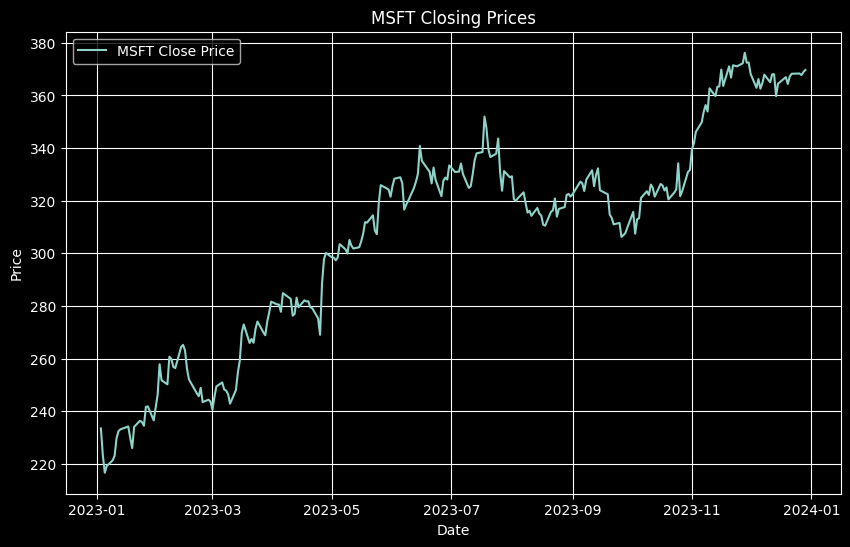

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

StockPricePlotter("MSFT").plot_closing_prices(START_DATE, END_DATE)
plt.gcf().savefig("msft_closing_price.png", bbox_inches="tight")


## Next Steps

Try replacing `WATCHLIST`, `START_DATE`, and `END_DATE` with your own research universe. For a more advanced project, combine these outputs into a scheduled report, a Streamlit dashboard, or a notebook template for repeated stock reviews.